In [3]:
#import libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [4]:
#1. import databases / data

In [40]:
conn=sqlite3.connect("/Users/kuldeepjain/Downloads/customer_churn.db")

sql_query=""" 
        SELECT name 
        FROM sqlite_master
        WHERE type='table'

"""

tables= pd.read_sql(sql_query,conn)

# create dataframe for each table

for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}" , conn)
    globals()[f"df_{table_name}"] =df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [41]:
print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [42]:
#print table names and column names 
conn=sqlite3.connect("/Users/kuldeepjain/Downloads/customer_churn.db")

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")

    #Get column information
    columns_query=f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

#close connection 
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [43]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [44]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [45]:
# a.  rename column - name
# b. drop columns - interest and pincode 
# c. change data type -dob
# d. data standardization- gender 
#e. fix missing values -country 

In [46]:
# a. rename col -name 

df_db_customer.rename(columns ={'name' :'customer_name'}, inplace=True)


In [47]:
#b.drop column -interest and pincode 

#df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
#df_db_customer.drop(df_db_customer.columns[6:],axis=1)
#df_db_customer.columns[-2:]

df_db_customer.drop(columns=['interests','pincode'],inplace=True)

In [48]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [49]:
#c. change data type -dob

df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [50]:
# d. data standardization-gernder

#df_db_customer['gender'].unique()
df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male','Women' :'Female'})


In [51]:
df_db_customer['gender']

0       Male
1       Male
2     Female
3       Male
4     Female
5     Female
6     Female
7       Male
8     Female
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: object

In [54]:
#e. fix missing values -country 

df_db_customer[df_db_customer["country"].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [58]:
df_db_customer[["country","state"]]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [63]:
#country and state -unique value pair 

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [66]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [67]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [74]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [79]:
date_col=['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [80]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [81]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [83]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [85]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [ ]:
#3 feature Engineering and data analysis 

In [90]:
#create a new column using existing col -churn flag
df_db_subscription['churn_flag']= np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [91]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [93]:
df_db_subscription.merge(df_db_customer , on='customerid' , how='left')

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0,arjun,Nepal,Kathmandu,Male,1993-10-29


In [96]:
#first fix support table duplicates then merger
df=(df_db_subscription
    .merge(df_db_customer , on='customerid' , how='left')
    .merge(df_db_support , on='customerid' , how='left'))

In [97]:
df.shape

(23, 20)

In [98]:
df_db_subscription.shape

(21, 12)

In [100]:
df_db_customer['customerid'].nunique()

21

In [101]:
df_db_support['customerid'].nunique()

7

In [102]:
df_db_subscription['customerid'].nunique()

21

In [103]:
df_db_support['customerid'].size

9

In [104]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [105]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [107]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [109]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [110]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [111]:
df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [112]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [113]:
df_db_support['customerid'].size

7

In [114]:
 # merge df
df=(df_db_subscription
    .merge(df_db_customer , on='customerid' , how='left')
    .merge(df_db_support , on='customerid' , how='left'))

In [115]:
df.shape

(21, 21)

In [117]:
df.to_csv('exported_churn_data.csv',index=False)

In [ ]:
# data analytics

In [ ]:
#1 churn rate 

In [118]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [120]:
df['churn_flag'].mean()*100

np.float64(28.57142857142857)

In [121]:
churn_rate=df['churn_flag'].mean()*100
print("Churn Rate =", round(churn_rate,2), "%")

Churn Rate = 28.57 %


In [123]:
#2 retention rate 
retention_rate=100-churn_rate
print("Retention Rate =", round(retention_rate,2), "%")

Retention Rate = 71.43 %


In [124]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [126]:
#3 churn by plan type 
df.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

In [127]:
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [ ]:
# 4 a . Churn by state +sum(revenue)& count of users 

In [133]:
statewise=(df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='statewise'))
print(statewise)

           state  statewise
0          Delhi      25.00
1      Karnataka     100.00
2      Kathmandu       0.00
3    Maharashtra       0.00
4      Meghalaya      66.67
5       Nagaland       0.00
6      Rajasthan       0.00
7      Telangana      50.00
8  Uttar Pradesh       0.00


In [134]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [135]:
#5 ARPU- average revenue per user
arpu =df['monthly_charges'].mean()
print('ARPU=', round(arpu,2))

ARPU= 18.85


In [139]:
# average customer tenure 
#count of days users has used our service :cancellation date else current date 
today=pd.Timestamp.today()

df['tenure_days'] =np.where(
    df['cancellation_date'].notna(),

    (df['cancellation_date']-df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1947.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1332.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2622.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [141]:
avg_tenure =df['tenure_days'].mean()
print("Avg Tenure (Days) =" , round(avg_tenure),0)

Avg Tenure (Days) = 1494 0


In [142]:
#7 revenue at risk - revenue lost fro  churned users 
df.loc[df['churn_flag']==1, 'monthly_charges'].sum()

np.float64(73.94)

In [144]:
revenue_at_risk=df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("revenue at risk(Rs Thousands) =", revenue_at_risk)

revenue at risk(Rs Thousands) = 73.94


In [145]:
# 8 Escalation Rate 
df['escalations'].unique()

array([nan, 'Y', 'N'], dtype=object)

In [149]:
(df['escalations']=='Y').mean()

np.float64(0.19047619047619047)

In [150]:
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate =",round(escalation_rate,2), "%")

Escalation Rate = 19.05 %


In [151]:
#9 Avg Compaint per user 
df['complaint_count'].sum()/df['customerid'].nunique()

np.float64(0.42857142857142855)

In [152]:
avg_complaints=df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Compaints Per user =",round(avg_complaints,2))

Avg Compaints Per user = 0.43


In [163]:
#10 Correlation Escalation vs churn 
df[['escalations','churn_flag']].dropna()

,escalations,churn_flag
1,Y,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [164]:
np.where(df['escalations']=='Y',1,0)

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [168]:
df['escalations']=np.where(df['escalations']=='Y',1,0)  # encoding string to int type 

In [169]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,escalation
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1947.0,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,1


In [170]:
corr_df=df[['escalations','churn_flag']].dropna()

#correlation = 
corr_df['escalations'].corr(df['churn_flag'])

np.float64(0.7669649888473702)

In [171]:
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalation vs churn is =", round(correlation,2))

Correlation between escalation vs churn is = 0.77


In [172]:
#11 
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [175]:
#11 churn risk - create a column usinf existing col

conditions=[
    (df['churn_score'] <50),
    (df['churn_score'] >=50 ) & (df['churn_score']<70),
    (df['churn_score'] >=70)
]

choices = ['low','med','high']

df['churn_risk']=np.select(conditions, choices , default='unknown')

In [176]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [177]:
#4 Visualization using matplotlib

In [178]:
df_visual = df.copy()

In [179]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'escalation', 'churn_risk'],
      dtype='object')

In [180]:
#4.1 Monthly Churn Trend (Time series KPI )

df_visual['cancellation_date'].dt.to_period('M')

0         NaT
1     2024-09
2         NaT
3         NaT
4     2024-02
5         NaT
6     2024-11
7         NaT
8         NaT
9         NaT
10        NaT
11    2024-05
12        NaT
13    2024-10
14        NaT
15        NaT
16        NaT
17        NaT
18    2024-09
19        NaT
20        NaT
Name: cancellation_date, dtype: period[M]

In [181]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

df_visual[df_visual['churn_flag'] ==1]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,escalation,churn_risk,cancellation_month
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,1,high,2024-09
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,1,high,2024-02
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,0,high,2024-11
11,0017-IUDMW,2023-03-17,Refferal,2024-03-17,Standard,Monthly,2024-05-01,Poor streaming quality,7.99,270,...,Female,1981-06-18,2024-04-10,1,25.0,1.0,411.0,1,high,2024-05
13,0019-EFAEP,2022-08-25,Refferal,2024-08-25,Basic,Monthly,2024-10-31,Switched to competitor,12.99,160,...,Female,1992-04-25,2024-09-27,1,30.0,1.0,798.0,1,high,2024-10
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,Male,1983-12-30,2024-09-14,0,90.0,2.0,366.0,0,high,2024-09


In [183]:
df_visual[df_visual['churn_flag'] ==1].groupby('cancellation_month').size()

cancellation_month
2024-02    1
2024-05    1
2024-09    2
2024-10    1
2024-11    1
Freq: M, dtype: int64

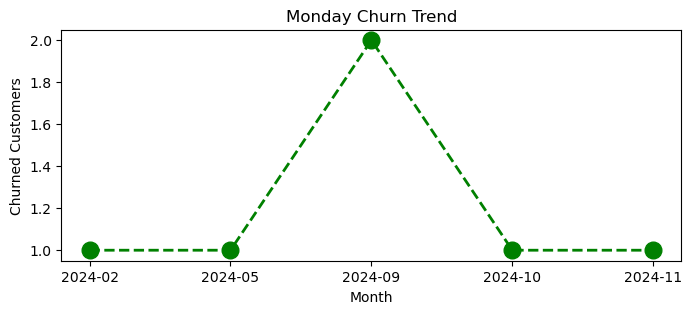

In [192]:
churn_trend=df_visual[df_visual['churn_flag'] ==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))

plt.plot(churn_trend.index.astype(str),churn_trend.values , color='green' ,marker='o' , linestyle='dashed',linewidth=2,markersize=12)

plt.title('Monday Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

In [195]:
#4.2 Churn by plan type 
df_visual.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

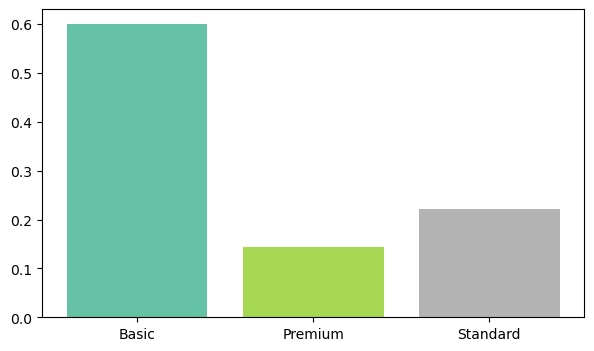

In [202]:
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()

#colors=['yellow','purple','blue']
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index,churn_plan.values,color=colors)

plt.show()

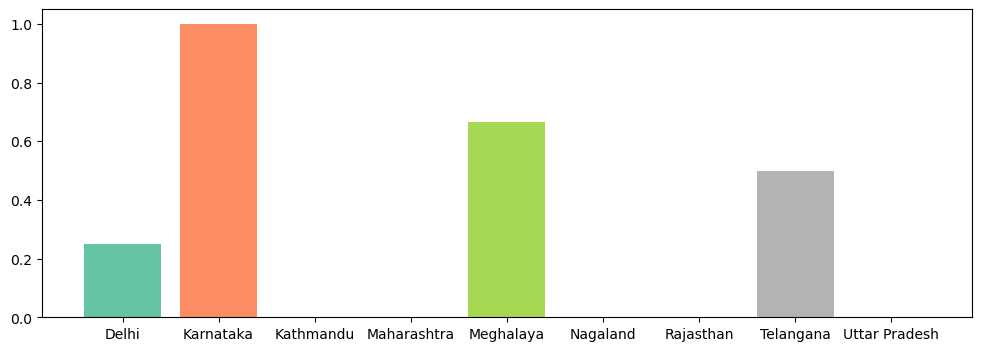

In [203]:
#4.3 Churn by States
churn_plan=df_visual.groupby('state')['churn_flag'].mean()

#colors=['yellow','purple','blue']
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index,churn_plan.values,color=colors)

plt.show()

In [ ]:
# Visualization using Seaborn

In [204]:
#encoding - convert str to numeric so tht we can find corr between features 
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'escalation', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [206]:
#df_encoded=
df[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [208]:
import warnings
warnings.filterwarnings("ignore")

In [212]:
#incorrect method of encoding - as numbers are not assigned on priority 

df_encoded=df[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'escalations','churn_risk']]

categorial_cols=['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col]=df_encoded[col].astype("category").cat.codes

In [211]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,2,0,12,0,0,1
1,1,0,91,1,1,0
2,0,1,34,0,0,1
3,1,0,8,0,0,1
4,2,1,88,1,1,0


<Axes: >

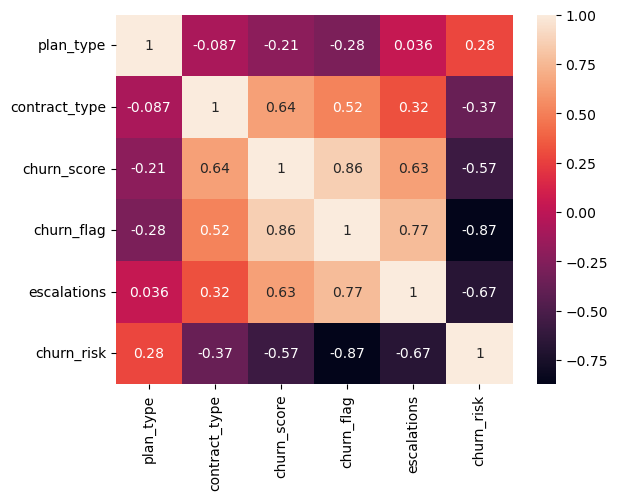

In [210]:
#Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(),annot=True)

In [214]:
df_visual['plan_type'].unique()

array(['Standard', 'Premium', 'Basic'], dtype=object)

In [215]:
df_visual['contract_type'].unique()

array(['Annual', 'Monthly'], dtype=object)

In [216]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [218]:
#correct method of encoding - as numbers are not assigned on priority 

df_encoded=df[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'escalations','churn_risk']]

order_mappings={
    'plan_type' :['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'], 
    'churn_risk':['low','med','high']
    
}

for col,order in order_mappings.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype("category"), categories=order,ordered=True).codes

In [219]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


In [220]:
df[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


<Axes: >

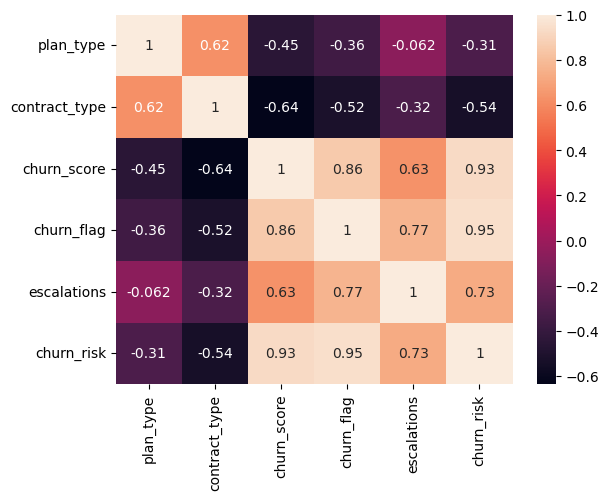

In [221]:
sns.heatmap(df_encoded.corr(),annot=True)

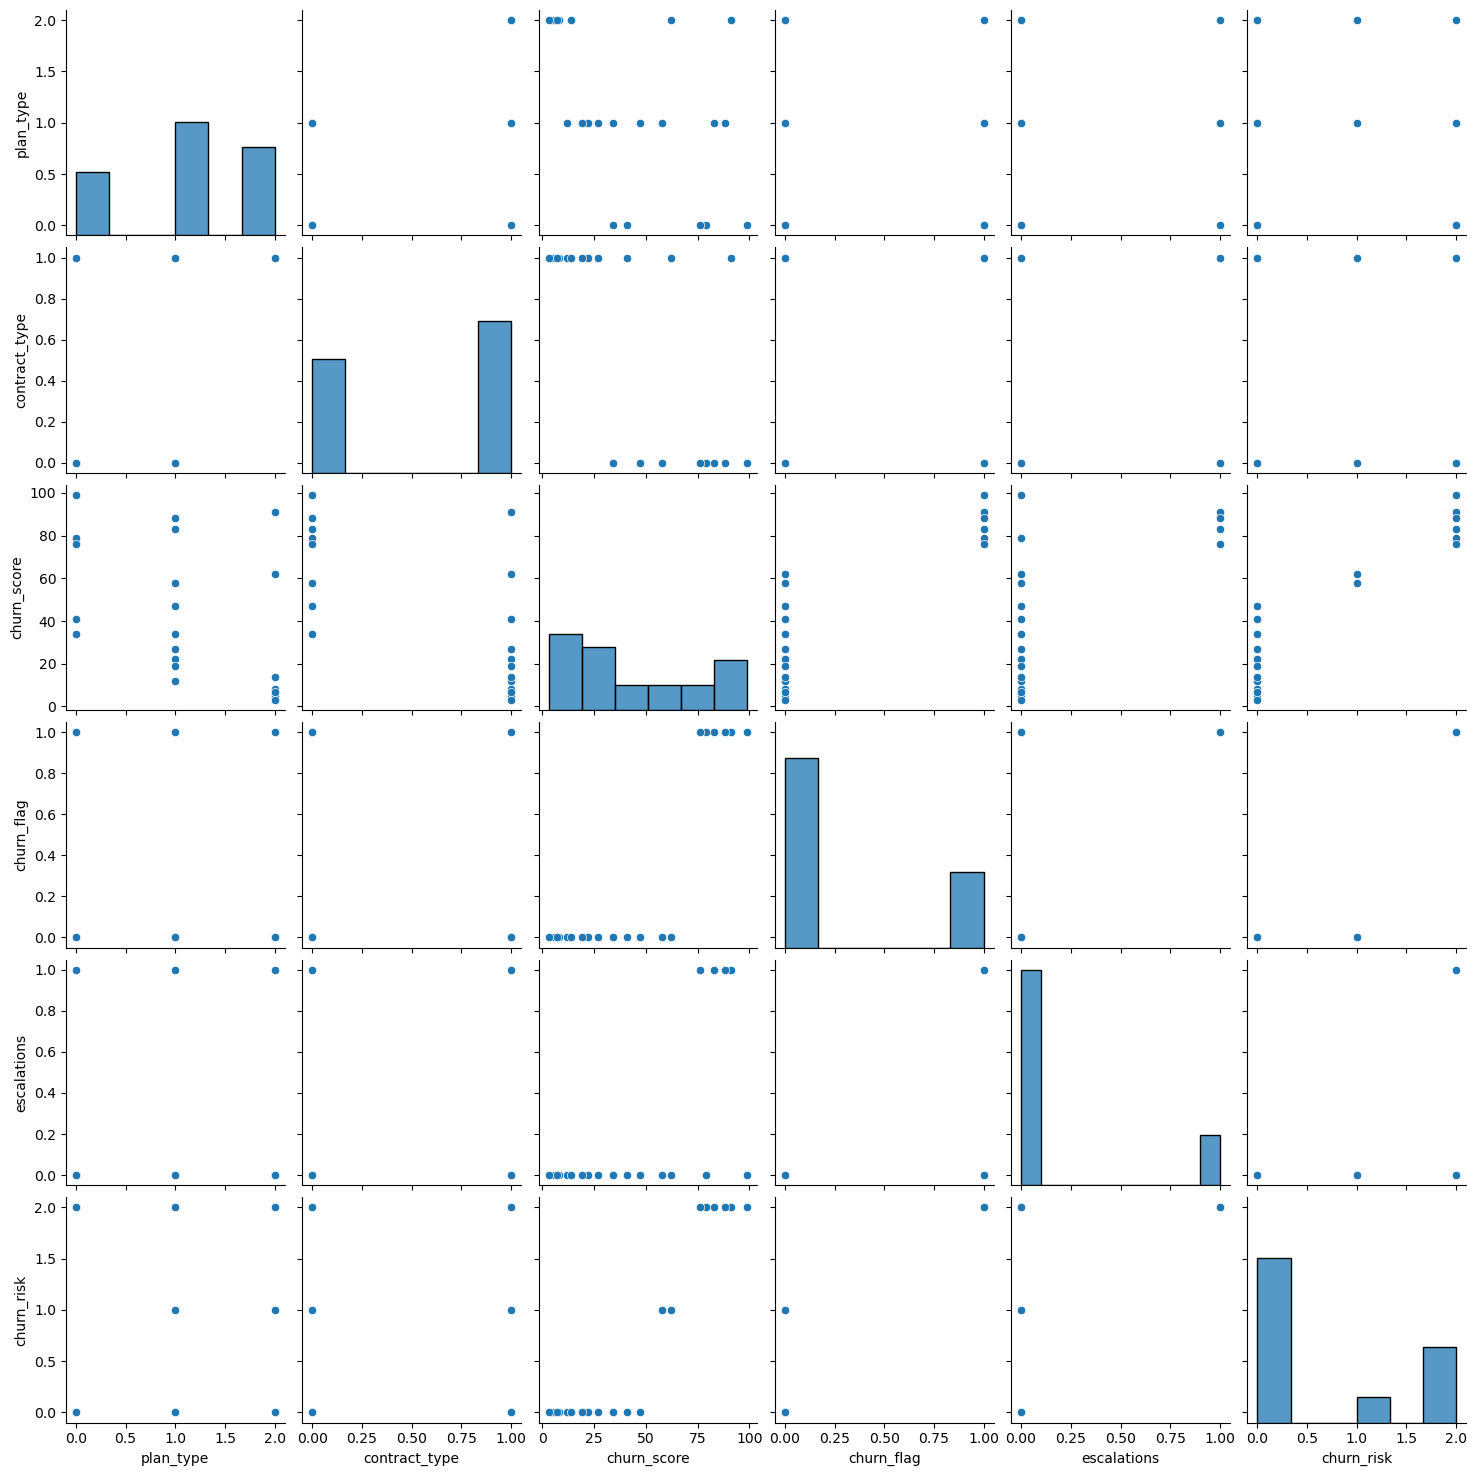

In [223]:
#pairpoint - relationship in a dataset
sns.pairplot(df_encoded)

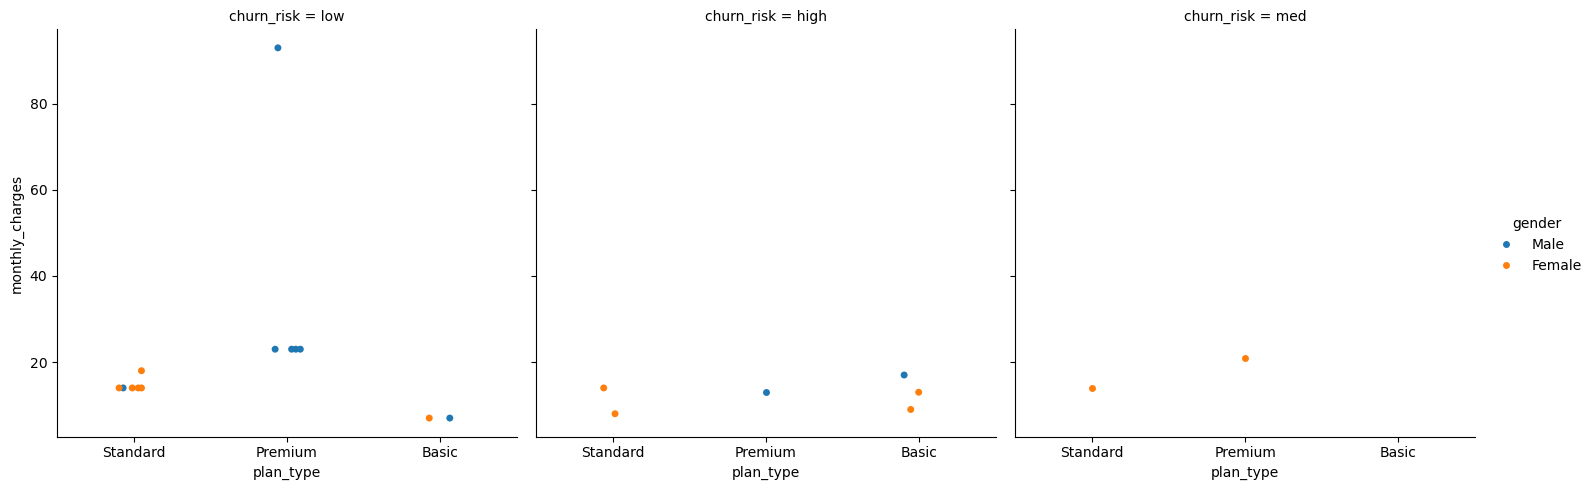

In [224]:
#catplt/Facegrid plot-multi-dim comparision

sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')

In [ ]:
#pivot table

In [225]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [226]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'escalation', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [228]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
        'monthly_charges':'sum',
        'customerid':'nunique',
        'churn_flag':'mean'
    
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
# Working with SQL in python(pandas)

In [230]:
# create db in sql
conn=sqlite3.connect('test_database.sqlite')

#table details 
conn.execute("Create table users (first_name Text,country Text , budget integer)")

# commit and save 
conn.commit()

In [234]:
#insert data

cursor =conn.cursor()

#write sql query to insert records in sql table 

cursor.execute(
    """
        INSERT INTO users VALUES 
            ('Madhav','India',5000),
            ('Rishabh','Germany',2500),
            ('Vishaka','India',3500)
        
    """
)
# commit and save 
conn.commit()

print("Data Inserted Successfully!")

Data Inserted Successfully!


In [237]:
# check inserted data in table 

conn=sqlite3.connect('test_database.sqlite')
query="""SELECT * FROM users"""

df_results=pd.read_sql(query,conn)

df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vishaka,India,3500


In [238]:
# aggregation

query="""
    SELECT country , SUM(budget) as total_budget
    FROM users
    Group BY country

"""

df_agg=pd.read_sql(query,conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [239]:
#always close the conn with dp once the task is over 
conn.close()